In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Products_v2.csv')
df.head()

,product_id,product_name,brand,category,supplier_id,unit_cost,selling_price,reorder_level,temp_code,weight_kg,launch_date,is_discontinued
0,1,Logitech Lipstick,Nestle,Office Supplies,1578,21.20,39.56,48,TMP-QRAPN4,29.08,2020-03-08,No
1,2,Nestle Monitor,KitchenAid,Electronics,1759,274.40,529.82,28,TMP-3NDSR1,23.38,2025-06-10,No
2,3,IKEA Dog Food,Puma,Clothing,802,299.41,496.23,103,TMP-UGCFJC,45.88,2023-06-12,No
3,4,Apple Desk,Philips,Home & Kitchen,7495,312.51,683.48,33,TMP-26LTZG,16.49,2022-11-29,Yes
4,5,Dell Lipstick,Apple,pet supplies,3048,424.48,831.54,16,TMP-YC9XK6,8.10,2022-12-29,No


In [3]:
inventory = pd.read_csv("Inventory_clean.csv")
orders = pd.read_csv("Orders_Clean.csv")
order_items = pd.read_csv("Orders_Items_clean.csv")

In [4]:
df.shape

(12347, 12)

In [5]:
df.isnull().sum()

product_id           0
product_name        82
brand                0
category           116
supplier_id          0
unit_cost           75
selling_price       90
reorder_level        0
temp_code            0
weight_kg            0
launch_date          0
is_discontinued      0
dtype: int64

In [6]:
missing_ids = df[df['product_name'].isna()]['product_id']
len(missing_ids)

82

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
inventory_matches = inventory[inventory['product_id'].isin(missing_ids)]

print("Inventory references:", len(inventory_matches))
inventory_matches.head()

Inventory references: 311


,inventory_id,product_id,warehouse_id,stock_quantity,reserved_stock,damaged_stock,last_updated
59,60,2476,3307,22.0,2.0,1.0,2024-01-29
146,147,2143,8573,229.0,58.0,8.0,2024-10-24
517,524,9518,7930,193.0,41.0,7.0,2023-11-07
642,650,903,3364,341.0,3.0,8.0,2023-08-08
698,706,2231,8477,232.0,6.0,7.0,2025-06-08


In [9]:
order_matches = order_items[order_items['product_id'].isin(missing_ids)]

print("Order Items references:", len(order_matches))
order_matches.head()

Order Items references: 564


,order_item_id,order_id,product_id,quantity,unit_price,discount,returned_flag
127,128,305,8391,7.0,1265.63,8.81,No
289,290,16429,3526,7.0,1337.37,30.66,No
682,683,43723,5987,3.0,1083.52,7.51,No
730,731,48635,11752,8.0,705.21,23.67,No
839,840,26109,3109,5.0,916.91,20.45,No


In [10]:
inventory.drop( inventory[inventory['product_id'].isin(missing_ids)].index,inplace=True)

In [11]:
order_items.drop( order_items[order_items['product_id'].isin(missing_ids)].index,inplace=True)

In [12]:
df.dropna(subset=['product_name'],inplace=True)

In [13]:
#inventory.to_csv('Inventory_Clean1.csv', index=False)

In [14]:
#order_items.to_csv('Order_Items_Clean1.csv', index=False)

In [15]:
df['category'].value_counts()

category
Office Supplies     1025
Beauty              1000
Grocery              988
Furniture            985
Clothing             984
Sports               969
Books                965
Automotive           957
Home & Kitchen       957
Electronics          956
Toys                 950
Pet Supplies         934
pet supplies          28
clothing              27
OfficeSupply          25
PetSupply             23
furniture             23
grocery               22
BOOKS                 22
office supplies       21
sports                21
TOYS                  21
SPORT                 20
CLOTHING              20
Groceries             20
AUTOMOTIVE            20
beauty                17
FURNITURE             16
BEAUTY                16
HOME & KITCHEN        16
toys                  16
automotive            15
ELECTRONICS           15
books                 15
Electronic            15
electronics           13
Home and Kitchen      12
Name: count, dtype: int64

In [16]:
df['category'] = df['category'].str.lower().str.strip()

In [17]:
df['category'] = df['category'].str.replace('officesupply','office supplies').str.replace('electronics','electronic')
df['category'] = df['category'].str.replace('home & kitchen','home and kitchen').str.replace('grocery','groceries')
df['category'] = df['category'].str.replace('sports','sport').str.replace('petsupply','pet supplies')


In [18]:
df.loc[df['category'].isna(), 'category'] = np.random.choice(
    ['office supplies', 'beauty'],
    size=df['category'].isna().sum())

In [19]:
df[['unit_cost','selling_price']]=df[['unit_cost','selling_price']].fillna(df[[
    'unit_cost','selling_price']].median())

In [20]:
num_cols = df.dtypes[df.dtypes!=object].index
print(num_cols)

Index(['product_id', 'supplier_id', 'unit_cost', 'selling_price',
       'reorder_level', 'weight_kg'],
      dtype='object')


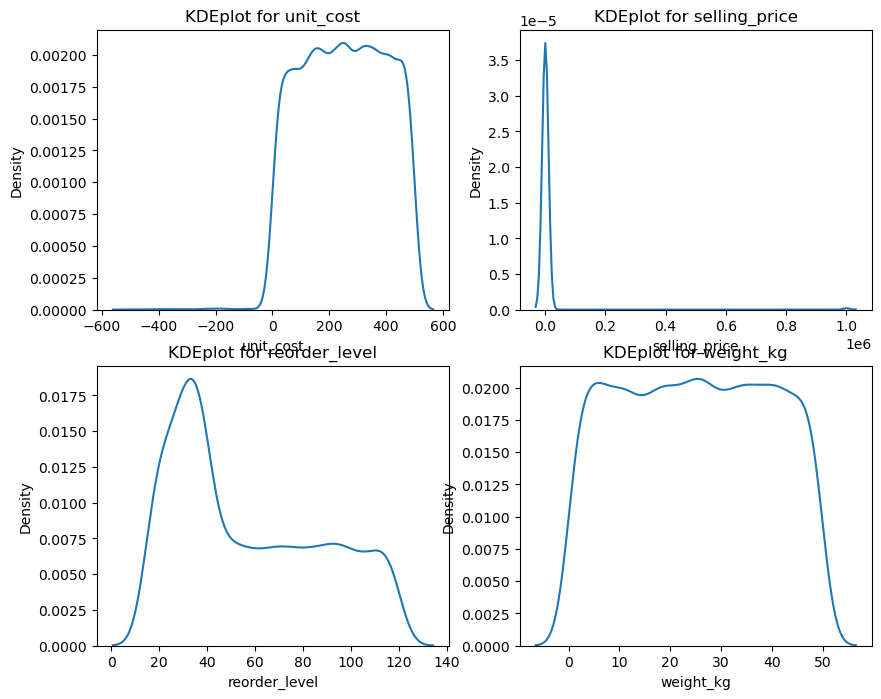

In [21]:
cols = num_cols[2:]
plt.figure(figsize=(10,8))
for i in range(len(cols)):
    plt.subplot(2,2,i+1)
    sns.kdeplot(data=df,x=cols[i])
    plt.title(f'KDEplot for {cols[i]}')
plt.show()

In [22]:
a = df[num_cols[2:]].describe(percentiles=[0.01,0.02,0.05,0.95,0.97,0.98,0.99]).T
a = a.iloc[:,3:]
a

,min,1%,2%,5%,50%,95%,97%,98%,99%,max
unit_cost,-496.09,6.2720,10.8052,25.492,253.735,475.300,484.9816,490.4700,495.9800,500.0
selling_price,2.90,11.3044,18.5028,42.292,403.690,873.216,928.4756,969.4064,1025.1036,999999.0
reorder_level,15.00,15.0000,16.0000,18.000,48.000,113.000,116.0000,117.0000,119.0000,120.0
weight_kg,0.05,0.5964,1.0128,2.490,24.950,47.368,48.4100,48.8972,49.4000,50.0


In [23]:
df['unit_cost'] = np.where(df['unit_cost']<df['unit_cost'].quantile(0.01),df['unit_cost'].quantile(0.01),df['unit_cost'])

In [24]:
df['selling_price'] = np.where(df['selling_price']>df['selling_price'].quantile(0.99),
                               df['selling_price'].quantile(0.99),df['selling_price'])

In [25]:
df.drop(columns=['temp_code'],inplace=True)

In [26]:
c = ['brand','product_name']
for i in c:
    print(df[i].value_counts())

brand
LEGO          847
KitchenAid    813
Whiskas       793
Nestle        792
Samsung       785
Apple         779
Adidas        770
IKEA          767
Nike          766
Sony          760
Canon         757
HP            747
Dell          726
Puma          723
Logitech      723
Philips       717
Name: count, dtype: int64
product_name
Nestle Phone         74
LEGO Toy Car         66
KitchenAid Mixer     62
KitchenAid Phone     62
HP Headphones        62
                     ..
 Apple Chair          1
 HP Mouse             1
 Logitech Laptop      1
 HP Laptop            1
 Sony Laptop          1
Name: count, Length: 414, dtype: int64


In [27]:
df['product_name'].unique()

array(['Logitech Lipstick', 'Nestle Monitor', 'IKEA Dog Food',
       'Apple Desk', 'Dell Lipstick', 'Apple Headphones',
       'Logitech Phone', 'KitchenAid Book', 'Nestle Book', 'HP Toy Car',
       'Nike Lipstick', 'Nike Laptop', 'Dell Chair', 'Logitech Toy Car',
       'Adidas Laptop', 'Apple Book', 'Philips Desk', 'Apple Monitor',
       'Nestle Phone', 'Nike Keyboard', 'Puma Monitor', 'LEGO Mouse',
       'Dell Book', 'Nike Chair', 'HP Football', 'Nike Mixer',
       'Samsung Phone', 'Dell Football', 'IKEA Desk', 'Nike Printer',
       'IKEA Toy Car', 'Puma Toy Car', 'Dell Bottle', 'Canon Bottle',
       'Adidas Bottle', 'Philips Football', 'Samsung Dog Food',
       'Sony Toy Car', 'Puma Phone', 'HP Desk', 'Philips Chair',
       'Nike Dog Food', ' Samsung Printer ', 'Whiskas Laptop',
       'Philips Dog Food', 'IKEA Laptop', 'Adidas Printer',
       'Canon Laptop', 'Samsung Book', 'Whiskas Phone', 'Adidas Lipstick',
       'Adidas Mouse', 'HP Printer', 'Samsung Toy Car',
      

In [28]:
df.to_csv('product_clean.csv',index=False)